In [1]:
!pip install rank_bm25 -q

In [2]:
import pandas as pd
import numpy as np
import pickle, os
from math import log2
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from rank_bm25 import BM25Okapi
from tqdm.notebook import tqdm

# ── Load data ────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/b22dckh131hongkhnhvn/arxiv-preprocessed/arxiv_preprocessed.csv')
df = df.dropna(subset=['text_recommend']).reset_index(drop=True)

# Mapping title → index
title_to_idx = pd.Series(df.index, index=df['title'].str.lower().str.strip())

print(f"✅ Dataset OK: {len(df):,} papers")
print(f"   Null text_recommend: {df['text_recommend'].isna().sum()}")
print(f"\nPhân bố category:")
print(df['categories'].str.split().explode().value_counts().head(8))
print(f"\nPhân bố năm:")
print(df['year'].value_counts().sort_index())

✅ Dataset OK: 100,000 papers
   Null text_recommend: 0

Phân bố category:
categories
cs.LG      55929
cs.CV      36138
stat.ML    32922
cs.AI      16708
cs.CL      16301
eess.IV     6432
cs.IR       4846
cs.RO       4054
Name: count, dtype: int64

Phân bố năm:
year
2018    19355
2019    28365
2020    37217
2021     9742
2022     2835
2023     1222
2024      797
2025      381
2026       86
Name: count, dtype: int64


## Vai trò của notebook

Notebook này đảm nhiệm phần **document-to-document recommendation**:

- Người dùng chọn hoặc nhập một paper mẫu.
- Hệ thống tìm các paper liên quan bằng TF-IDF, BM25 và raw cosine.
- Phần này khác `member1`: query không phải câu tìm kiếm tự do, mà là một document/paper đã có trong corpus.

Phần bổ sung bên dưới sửa title matching, sửa NDCG chuẩn về khoảng 0..1 và thêm nhận xét so sánh.


In [3]:
# ── Model 1: TF-IDF ──────────────────────────────────────────
print("Building TF-IDF matrix...")
tfidf_vectorizer = TfidfVectorizer(
    max_features = 40_000,
    ngram_range  = (1, 2),
    min_df       = 2,
    sublinear_tf = True,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_recommend'])
print(f"  TF-IDF matrix: {tfidf_matrix.shape}")

# ── Model 2: Raw Cosine (CountVectorizer) ────────────────────
print("Building Count matrix...")
count_vec = CountVectorizer(max_features=30_000, min_df=2)
count_mat = count_vec.fit_transform(df['text_recommend'])
print(f"  Count matrix:  {count_mat.shape}")

# ── Model 3: BM25 ────────────────────────────────────────────
print("Building BM25 index (mất ~2-3 phút)...")
corpus_tokens = [str(t).split() for t in tqdm(df['text_recommend'])]
bm25_d2d      = BM25Okapi(corpus_tokens, k1=1.5, b=0.75)
print(f"  BM25 index:    {len(corpus_tokens):,} docs")

print("\n✅ Tất cả models built xong!")

Building TF-IDF matrix...
  TF-IDF matrix: (100000, 40000)
Building Count matrix...
  Count matrix:  (100000, 30000)
Building BM25 index (mất ~2-3 phút)...


  0%|          | 0/100000 [00:00<?, ?it/s]

  BM25 index:    100,000 docs

✅ Tất cả models built xong!


In [4]:
import re


def _title_tokens(value: str) -> set:
    tokens = re.findall(r'[a-z0-9]+', str(value).lower())
    # Chuẩn hóa số nhiều đơn giản để query "network" khớp "networks".
    return {t[:-1] if len(t) > 3 and t.endswith('s') else t for t in tokens}


title_tokens = df['title'].fillna('').apply(_title_tokens).to_list()
title_norm = df['title'].fillna('').str.lower().str.strip()
id_norm = df['id'].astype(str).str.lower().str.strip()


# ── Helper: tìm index của paper theo title hoặc id ───────────────────
def _find_idx(paper_title: str, verbose: bool = True,
              min_token_overlap: float = 0.6):
    query = str(paper_title).lower().strip()

    # Ưu tiên id để tránh fuzzy match sai paper.
    id_match = df.index[id_norm == query]
    if len(id_match) > 0:
        idx = id_match[0]
        if verbose:
            print(f"[*] Paper mẫu: {df.loc[idx, 'title']}")
        return idx

    exact = df.index[title_norm == query]
    if len(exact) > 0:
        idx = exact[0]
        if verbose:
            print(f"[*] Paper mẫu: {df.loc[idx, 'title']}")
        return idx

    contains = df.index[title_norm.str.contains(query, regex=False)]
    if len(contains) > 0:
        idx = contains[0]
        if verbose:
            print(f"[*] Tìm thấy gần đúng: {df.loc[idx, 'title']}")
        return idx

    query_tokens = _title_tokens(query)
    if query_tokens:
        scores = [
            len(query_tokens & words) / len(query_tokens)
            for words in title_tokens
        ]
        best_idx = int(np.argmax(scores))
        if scores[best_idx] >= min_token_overlap:
            if verbose:
                print(f"[*] Token-overlap match: {df.loc[best_idx, 'title']}")
            return best_idx

        if verbose:
            top_idx = np.argsort(scores)[::-1][:3]
            print(f"❌ Không tìm thấy paper đủ chắc chắn cho: '{paper_title}'")
            print("   Gợi ý title gần nhất:")
            for i in top_idx:
                if scores[i] > 0:
                    print(f"   - {df.loc[i, 'title']}")
        return None

    print(f"❌ Không tìm thấy paper: '{paper_title}'")
    return None


# ── Hàm D2D: TF-IDF ─────────────────────────────────────────
def get_related_tfidf(paper_title: str, top_k: int = 10,
                      verbose: bool = True) -> pd.DataFrame:
    """Document-to-Document Retrieval dùng TF-IDF + Cosine Similarity"""
    idx = _find_idx(paper_title, verbose)
    if idx is None:
        return pd.DataFrame()

    scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    scores[idx] = 0
    top_idx = scores.argsort()[::-1][:top_k]

    res = df.iloc[top_idx][['id', 'title', 'categories', 'year']].copy()
    res['similarity_score'] = scores[top_idx].round(4)
    res['query_categories'] = df.loc[idx, 'categories']
    res['method'] = 'TF-IDF D2D'
    return res.reset_index(drop=True)


# ── Hàm D2D: BM25 ───────────────────────────────────────────
def get_related_bm25(paper_title: str, top_k: int = 10,
                     verbose: bool = True) -> pd.DataFrame:
    """Document-to-Document Retrieval dùng BM25"""
    idx = _find_idx(paper_title, verbose)
    if idx is None:
        return pd.DataFrame()

    query_tokens = corpus_tokens[idx]
    scores = np.array(bm25_d2d.get_scores(query_tokens), dtype=np.float64)
    scores[idx] = 0
    top_idx = scores.argsort()[::-1][:top_k]

    res = df.iloc[top_idx][['id', 'title', 'categories', 'year']].copy()
    res['similarity_score'] = scores[top_idx].round(4)
    res['query_categories'] = df.loc[idx, 'categories']
    res['method'] = 'BM25 D2D'
    return res.reset_index(drop=True)


# ── Hàm D2D: Raw Cosine ──────────────────────────────────────
def get_related_cosine(paper_title: str, top_k: int = 10,
                       verbose: bool = True) -> pd.DataFrame:
    """Document-to-Document Retrieval dùng Raw Cosine, không TF-IDF weighting"""
    idx = _find_idx(paper_title, verbose)
    if idx is None:
        return pd.DataFrame()

    scores = cosine_similarity(count_mat[idx], count_mat).flatten()
    scores[idx] = 0
    top_idx = scores.argsort()[::-1][:top_k]

    res = df.iloc[top_idx][['id', 'title', 'categories', 'year']].copy()
    res['similarity_score'] = scores[top_idx].round(4)
    res['query_categories'] = df.loc[idx, 'categories']
    res['method'] = 'Cosine D2D'
    return res.reset_index(drop=True)


print("✅ Các hàm D2D ready!")


✅ Các hàm D2D ready!


In [5]:
TEST_PAPERS = [
    "Attention Is All You Need",
    "BERT pre-training deep bidirectional",
    "graph neural network node classification",
]

for paper in TEST_PAPERS:
    print(f"\n{'='*65}")
    print(f"  Paper mẫu: \"{paper}\"")
    print('='*65)

    for name, fn in [
        ('TF-IDF D2D', get_related_tfidf),
        ('BM25 D2D',   get_related_bm25),
        ('Cosine D2D', get_related_cosine),
    ]:
        res = fn(paper, top_k=3, verbose=False)
        if res.empty: continue
        print(f"\n  [{name}]")
        for _, row in res.iterrows():
            print(f"  {row['similarity_score']:.4f}  "
                  f"{row['title'][:58]}")
            print(f"           {row['categories']}  ({row['year']})")


  Paper mẫu: "Attention Is All You Need"

  [TF-IDF D2D]
  0.3738  Parallel Attention Mechanisms in Neural Machine Translatio
           cs.CL cs.AI  (2018)
  0.3220  Transformer++
           cs.CL cs.LG stat.ML  (2020)
  0.3183  Graph Transformer for Graph-to-Sequence Learning
           cs.CL cs.AI  (2019)

  [BM25 D2D]
  197.3762  Joint Source-Target Self Attention with Locality Constrain
           cs.CL cs.LG  (2019)
  184.0380  Very Deep Transformers for Neural Machine Translation
           cs.CL  (2020)
  183.8707  Parallel Attention Mechanisms in Neural Machine Translatio
           cs.CL cs.AI  (2018)

  [Cosine D2D]
  0.5648  Training Deeper Neural Machine Translation Models with Tra
           cs.CL cs.AI cs.LG  (2018)
  0.5410  Parallel Attention Mechanisms in Neural Machine Translatio
           cs.CL cs.AI  (2018)
  0.5405  Data Diversification: A Simple Strategy For Neural Machine
           cs.CL cs.LG  (2020)

  Paper mẫu: "BERT pre-training deep bidirectional"

  [T

In [6]:
def compare_d2d_methods(paper_title: str, top_k: int = 5):
    """In kết quả 3 method song song để dễ so sánh"""
    idx = _find_idx(paper_title)
    if idx is None: return

    query_cats = set(str(df.loc[idx, 'categories']).split())
    print(f"  Category gốc: {df.loc[idx, 'categories']}")
    print(f"  Năm:          {df.loc[idx, 'year']}")

    for name, fn in [
        ('TF-IDF D2D', get_related_tfidf),
        ('BM25 D2D',   get_related_bm25),
        ('Cosine D2D', get_related_cosine),
    ]:
        res = fn(paper_title, top_k, verbose=False)
        if res.empty: continue

        # Đánh dấu kết quả relevant (cùng category)
        hits = sum(
            1 for _, row in res.iterrows()
            if len(query_cats &
                   set(str(row['categories']).split())) > 0
        )
        print(f"\n  [{name}]  — Precision@{top_k} = {hits/top_k:.0%}")
        for _, row in res.iterrows():
            rel = '✅' if len(query_cats &
                              set(str(row['categories']).split())) > 0 else '❌'
            print(f"  {rel} {row['similarity_score']:.4f}  "
                  f"{row['title'][:52]}")
            print(f"       {row['categories']}  ({row['year']})")

compare_d2d_methods("Attention Is All You Need", top_k=5)
compare_d2d_methods("graph neural network node", top_k=5)

[*] Paper mẫu: Attention Is All You Need
  Category gốc: cs.CL cs.LG
  Năm:          2023

  [TF-IDF D2D]  — Precision@5 = 100%
  ✅ 0.3738  Parallel Attention Mechanisms in Neural Machine Tran
       cs.CL cs.AI  (2018)
  ✅ 0.3220  Transformer++
       cs.CL cs.LG stat.ML  (2020)
  ✅ 0.3183  Graph Transformer for Graph-to-Sequence Learning
       cs.CL cs.AI  (2019)
  ✅ 0.3181  The Evolved Transformer
       cs.LG cs.CL cs.NE stat.ML  (2019)
  ✅ 0.3075  Scaling Neural Machine Translation
       cs.CL  (2018)

  [BM25 D2D]  — Precision@5 = 100%
  ✅ 197.3762  Joint Source-Target Self Attention with Locality Con
       cs.CL cs.LG  (2019)
  ✅ 184.0380  Very Deep Transformers for Neural Machine Translatio
       cs.CL  (2020)
  ✅ 183.8707  Parallel Attention Mechanisms in Neural Machine Tran
       cs.CL cs.AI  (2018)
  ✅ 176.4575  Training Deeper Neural Machine Translation Models wi
       cs.CL cs.AI cs.LG  (2018)
  ✅ 175.9201  Transformer++
       cs.CL cs.LG stat.ML  (2020)

  [Cosine 

In [7]:
cat_sets = df['categories'].fillna('').apply(lambda x: set(str(x).split())).to_list()

category_to_indices = {}
for i, cats in enumerate(cat_sets):
    for cat in cats:
        category_to_indices.setdefault(cat, set()).add(i)


def relevant_indices_for(query_cats: set, query_idx: int) -> set:
    relevant = set()
    for cat in query_cats:
        relevant |= category_to_indices.get(cat, set())
    relevant.discard(query_idx)
    return relevant


def precision_at_k(top_idx, relevant_indices, k):
    hits = sum(1 for i in top_idx[:k] if i in relevant_indices)
    return hits / k


def ndcg_at_k(top_idx, relevant_indices, k, total_relevant=None):
    """NDCG chuẩn hóa về 0..1 với relevance nhị phân theo category overlap."""
    relevances = [1 if i in relevant_indices else 0 for i in top_idx[:k]]
    dcg = sum(rel / log2(rank + 2) for rank, rel in enumerate(relevances))

    ideal_len = min(total_relevant if total_relevant is not None else k, k)
    idcg = sum(1 / log2(rank + 2) for rank in range(ideal_len))
    return dcg / idcg if idcg > 0 else 0


def recall_at_k(top_idx, relevant_indices, k, total_relevant):
    hits = sum(1 for i in top_idx[:k] if i in relevant_indices)
    return hits / total_relevant if total_relevant > 0 else 0


print("✅ Metrics functions ready! Category sets đã được tiền xử lý.")


✅ Metrics functions ready! Category sets đã được tiền xử lý.


In [8]:
def evaluate_all_methods(test_size: int = 200,
                          k_values: list = [5, 10, 20]) -> pd.DataFrame:
    """
    Đánh giá cả 3 D2D variant + Random baseline.
    Metrics: Precision@K, Recall@K, NDCG@K.
    """
    np.random.seed(42)
    test_indices = np.random.choice(len(df), test_size, replace=False)

    records = []

    for idx in tqdm(test_indices, desc="Evaluating"):
        query_cats = cat_sets[idx]
        relevant_indices = relevant_indices_for(query_cats, idx)
        total_relevant = len(relevant_indices)

        ranked_lists = {}

        sc = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
        sc[idx] = 0
        ranked_lists['TF-IDF D2D'] = sc.argsort()[::-1]

        sc = np.array(bm25_d2d.get_scores(corpus_tokens[idx]))
        sc[idx] = 0
        ranked_lists['BM25 D2D'] = sc.argsort()[::-1]

        sc = cosine_similarity(count_mat[idx], count_mat).flatten()
        sc[idx] = 0
        ranked_lists['Cosine D2D'] = sc.argsort()[::-1]

        rand_idx = np.random.permutation([i for i in range(len(df)) if i != idx])
        ranked_lists['Random'] = rand_idx

        for method_name, ranked in ranked_lists.items():
            for k in k_values:
                top_idx = ranked[:k]
                p = precision_at_k(top_idx, relevant_indices, k)
                r = recall_at_k(top_idx, relevant_indices, k, total_relevant)
                n = ndcg_at_k(top_idx, relevant_indices, k, total_relevant)
                f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
                records.append({
                    'method': method_name,
                    'k': k,
                    'P@K': round(p, 4),
                    'R@K': round(r, 4),
                    'NDCG@K': round(n, 4),
                    'F1@K': round(f1, 4),
                })

    result_df = pd.DataFrame(records)
    summary = result_df.groupby(['method', 'k'])[
        ['P@K', 'R@K', 'NDCG@K', 'F1@K']
    ].mean().round(4)

    print("\n" + "=" * 65)
    print("  EVALUATION KẾT QUẢ — Document-to-Document Retrieval")
    print("=" * 65)
    print(summary.to_string())

    print("\n  Cải thiện so với Random baseline (Precision@10):")
    for m in ['TF-IDF D2D', 'BM25 D2D', 'Cosine D2D']:
        p_model = summary.loc[(m, 10), 'P@K']
        p_random = summary.loc[('Random', 10), 'P@K']
        improvement = (p_model - p_random) / p_random * 100
        print(f"    {m:<15}: {p_model:.4f} (+{improvement:.1f}% so với random {p_random:.4f})")

    result_df.to_csv('/kaggle/working/tv3_evaluation.csv', index=False)
    return result_df, summary


result_df, summary = evaluate_all_methods(test_size=200, k_values=[5, 10, 20])


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]


  EVALUATION KẾT QUẢ — Document-to-Document Retrieval
                  P@K     R@K  NDCG@K    F1@K
method     k                                 
BM25 D2D   5   0.8990  0.0001  0.9116  0.0003
           10  0.8930  0.0002  0.9026  0.0005
           20  0.8835  0.0005  0.8928  0.0010
Cosine D2D 5   0.8660  0.0001  0.8722  0.0002
           10  0.8590  0.0002  0.8653  0.0005
           20  0.8462  0.0004  0.8541  0.0009
Random     5   0.4920  0.0001  0.4974  0.0001
           10  0.4935  0.0001  0.4963  0.0002
           20  0.4822  0.0002  0.4879  0.0004
TF-IDF D2D 5   0.8840  0.0001  0.8872  0.0002
           10  0.8780  0.0002  0.8819  0.0005
           20  0.8765  0.0005  0.8796  0.0009

  Cải thiện so với Random baseline (Precision@10):
    TF-IDF D2D     : 0.8780 (+77.9% so với random 0.4935)
    BM25 D2D       : 0.8930 (+81.0% so với random 0.4935)
    Cosine D2D     : 0.8590 (+74.1% so với random 0.4935)


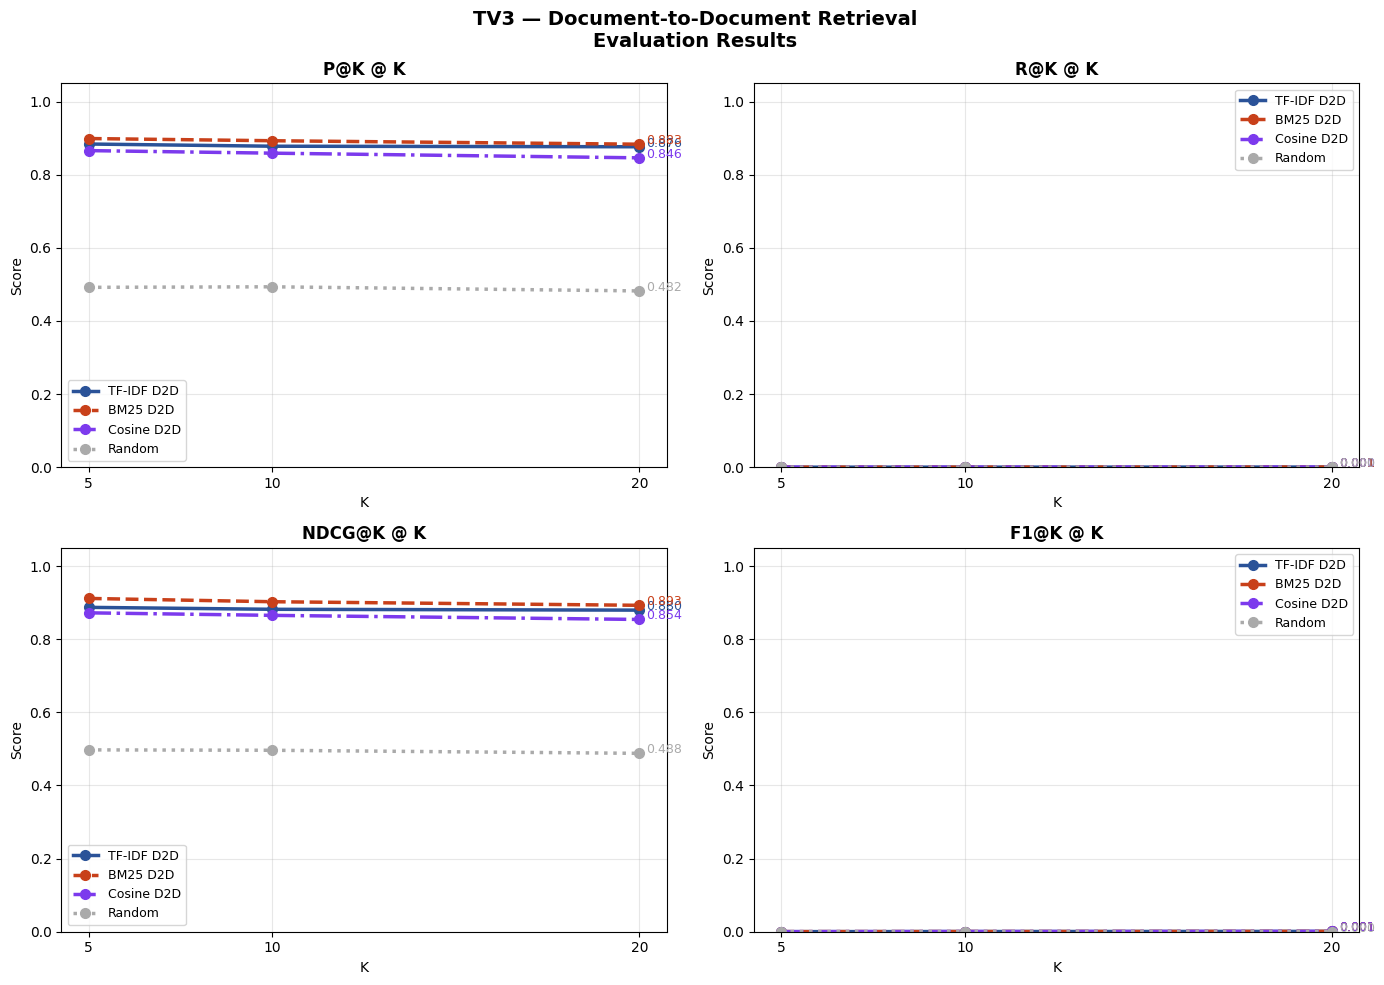

Saved tv3_evaluation_chart.png!


In [9]:
def plot_evaluation(summary):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('TV3 — Document-to-Document Retrieval\nEvaluation Results',
                 fontsize=14, fontweight='bold')

    colors = {
        'TF-IDF D2D': '#2a5298',
        'BM25 D2D':   '#c8401a',
        'Cosine D2D': '#7c3aed',
        'Random':     '#aaaaaa',
    }
    ls_map = {
        'TF-IDF D2D': '-',
        'BM25 D2D':   '--',
        'Cosine D2D': '-.',
        'Random':     ':',
    }
    k_vals  = [5, 10, 20]
    methods = ['TF-IDF D2D', 'BM25 D2D', 'Cosine D2D', 'Random']

    for ax, metric in zip(axes.flatten(),
                          ['P@K', 'R@K', 'NDCG@K', 'F1@K']):
        for m in methods:
            vals = []
            for k in k_vals:
                try:
                    vals.append(summary.loc[(m, k), metric])
                except:
                    vals.append(0)
            ax.plot(k_vals, vals,
                    label=m,
                    color=colors[m],
                    linewidth=2.5,
                    marker='o',
                    markersize=7,
                    linestyle=ls_map[m])
            # Annotate điểm cuối
            ax.annotate(f'{vals[-1]:.3f}',
                        xy=(k_vals[-1], vals[-1]),
                        xytext=(5, 0),
                        textcoords='offset points',
                        fontsize=9,
                        color=colors[m])

        ax.set_title(f'{metric} @ K', fontweight='bold')
        ax.set_xlabel('K')
        ax.set_ylabel('Score')
        ax.set_xticks(k_vals)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/tv3_evaluation_chart.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved tv3_evaluation_chart.png!")

plot_evaluation(summary)

[*] Paper mẫu: Attention Is All You Need


/tmp/ipykernel_57/220426806.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([rel_scores, nrel_scores],


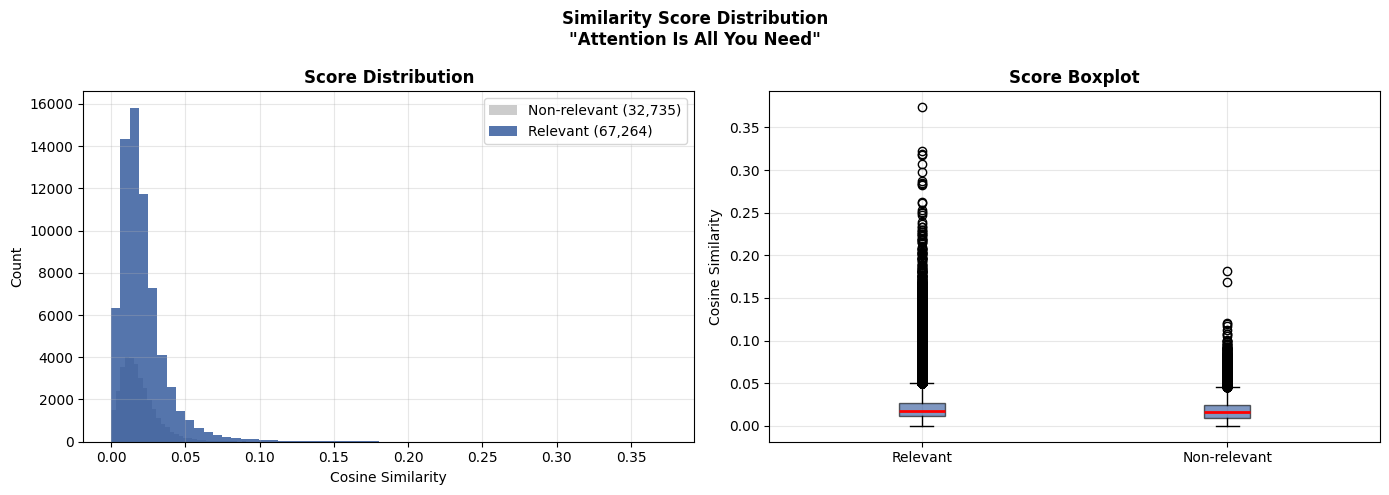


Relevant   — Mean: 0.0215  Std: 0.0184
Non-relevant — Mean: 0.0183  Std: 0.0124


In [10]:
def plot_score_distribution(paper_title: str):
    """
    Vẽ phân bố similarity score giữa relevant vs non-relevant
    Chứng minh hệ thống phân biệt tốt — hay dùng trong báo cáo
    """
    idx = _find_idx(paper_title)
    if idx is None: return

    query_cats = set(str(df.loc[idx, 'categories']).split())
    scores     = linear_kernel(
        tfidf_matrix[idx], tfidf_matrix
    ).flatten()
    scores[idx] = 0

    rel_scores  = [scores[i] for i in range(len(df))
                   if i != idx and
                   len(query_cats &
                       set(str(df.loc[i,'categories']).split())) > 0]
    nrel_scores = [scores[i] for i in range(len(df))
                   if i != idx and
                   len(query_cats &
                       set(str(df.loc[i,'categories']).split())) == 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Similarity Score Distribution\n"{paper_title[:55]}"',
                 fontweight='bold')

    # ── Histogram ────────────────────────────────────────────
    axes[0].hist(nrel_scores, bins=60, alpha=0.6,
                 color='#aaaaaa', label=f'Non-relevant ({len(nrel_scores):,})')
    axes[0].hist(rel_scores,  bins=60, alpha=0.8,
                 color='#2a5298', label=f'Relevant ({len(rel_scores):,})')
    axes[0].set_title('Score Distribution', fontweight='bold')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Boxplot ──────────────────────────────────────────────
    axes[1].boxplot([rel_scores, nrel_scores],
                    labels=['Relevant', 'Non-relevant'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#2a5298', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title('Score Boxplot', fontweight='bold')
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/tv3_score_dist.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nRelevant   — Mean: {np.mean(rel_scores):.4f}  "
          f"Std: {np.std(rel_scores):.4f}")
    print(f"Non-relevant — Mean: {np.mean(nrel_scores):.4f}  "
          f"Std: {np.std(nrel_scores):.4f}")

plot_score_distribution("Attention Is All You Need")

In [11]:
os.makedirs('/kaggle/working/models_tv3', exist_ok=True)

# TF-IDF
pickle.dump(tfidf_vectorizer,
            open('/kaggle/working/models_tv3/tv3_tfidf_vec.pkl','wb'))
pickle.dump(tfidf_matrix,
            open('/kaggle/working/models_tv3/tv3_tfidf_mat.pkl','wb'))

# Count / Cosine
pickle.dump(count_vec,
            open('/kaggle/working/models_tv3/tv3_count_vec.pkl','wb'))
pickle.dump(count_mat,
            open('/kaggle/working/models_tv3/tv3_count_mat.pkl','wb'))

# BM25
pickle.dump(bm25_d2d,
            open('/kaggle/working/models_tv3/tv3_bm25.pkl','wb'))

# DataFrame index (để web app dùng)
df[['id','title','abstract','categories','year']].to_csv(
    '/kaggle/working/models_tv3/df_index.csv', index=True
)

print("✅ TV3 hoàn tất! Files đã lưu:")
for f in sorted(os.listdir('/kaggle/working/models_tv3')):
    size = os.path.getsize(
        f'/kaggle/working/models_tv3/{f}'
    ) / 1024 / 1024
    print(f"  {f:<40} {size:.1f} MB")

✅ TV3 hoàn tất! Files đã lưu:
  df_index.csv                             119.3 MB
  tv3_bm25.pkl                             88.0 MB
  tv3_count_mat.pkl                        83.2 MB
  tv3_count_vec.pkl                        0.8 MB
  tv3_tfidf_mat.pkl                        114.9 MB
  tv3_tfidf_vec.pkl                        1.7 MB


## Bổ sung nhận xét đánh giá

Kết quả Precision@K cao cho thấy các phương pháp D2D tìm được nhiều paper cùng lĩnh vực với paper mẫu. Tuy nhiên ground-truth dựa trên category overlap còn khá rộng, đặc biệt các category lớn như `cs.LG`, `cs.CV`, `stat.ML`, nên cần trình bày đây là đánh giá tương đối. Sau khi sửa NDCG, chỉ số này phải nằm trong khoảng 0..1; nếu lớn hơn 1 thì công thức vẫn chưa đúng.


In [12]:
def summarize_d2d_results(summary):
    """In kết luận ngắn gọn từ bảng summary sau evaluate_all_methods."""
    metric = 'P@K'
    k = 10
    candidates = ['TF-IDF D2D', 'BM25 D2D', 'Cosine D2D']
    best_method = max(candidates, key=lambda m: summary.loc[(m, k), metric])

    print(f"Phương pháp tốt nhất theo Precision@{k}: {best_method}")
    for method in candidates:
        p = summary.loc[(method, k), 'P@K']
        ndcg = summary.loc[(method, k), 'NDCG@K']
        print(f"  {method:<12} P@{k}={p:.4f} | NDCG@{k}={ndcg:.4f}")


# Chạy sau khi có biến summary:
summarize_d2d_results(summary)


Phương pháp tốt nhất theo Precision@10: BM25 D2D
  TF-IDF D2D   P@10=0.8780 | NDCG@10=0.8819
  BM25 D2D     P@10=0.8930 | NDCG@10=0.9026
  Cosine D2D   P@10=0.8590 | NDCG@10=0.8653
